In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

In [2]:
#Load In Data 
x_train = np.loadtxt('TrainingData_x.txt', delimiter = ',')
x_test = np.loadtxt('TestingData_x.txt', delimiter = ',')
y_train = np.loadtxt('TrainingData_y.txt', delimiter = ',')
y_test = np.loadtxt('TestingData_y.txt', delimiter = ',')

In [3]:
#Part 1: Nonlinear Transform + Over/Underfitting
#Transform individual element. 
def transform(x, q):
    z = np.zeros(q+1)
    for i in range(0, q+1):
        z[i] = x ** i 
    return z

In [4]:
#Transform entire array. 
def getZ(x, q):
    z = np.zeros((len(x), q + 1))
    for i in range(0, len(x)):
        z[i] = transform(x[i], q)
    return z

In [5]:
#Set z + transpose
z_train = [getZ(x_train, 2), getZ(x_train, 3), getZ(x_train, 19)]
z_train

[array([[ 1.  , -9.5 , 90.25],
        [ 1.  , -8.5 , 72.25],
        [ 1.  , -7.5 , 56.25],
        [ 1.  , -6.5 , 42.25],
        [ 1.  , -5.5 , 30.25],
        [ 1.  , -4.5 , 20.25],
        [ 1.  , -3.5 , 12.25],
        [ 1.  , -2.5 ,  6.25],
        [ 1.  , -1.5 ,  2.25],
        [ 1.  , -0.5 ,  0.25],
        [ 1.  ,  0.5 ,  0.25],
        [ 1.  ,  1.5 ,  2.25],
        [ 1.  ,  2.5 ,  6.25],
        [ 1.  ,  3.5 , 12.25],
        [ 1.  ,  4.5 , 20.25],
        [ 1.  ,  5.5 , 30.25],
        [ 1.  ,  6.5 , 42.25],
        [ 1.  ,  7.5 , 56.25],
        [ 1.  ,  8.5 , 72.25],
        [ 1.  ,  9.5 , 90.25]]),
 array([[ 1.00000e+00, -9.50000e+00,  9.02500e+01, -8.57375e+02],
        [ 1.00000e+00, -8.50000e+00,  7.22500e+01, -6.14125e+02],
        [ 1.00000e+00, -7.50000e+00,  5.62500e+01, -4.21875e+02],
        [ 1.00000e+00, -6.50000e+00,  4.22500e+01, -2.74625e+02],
        [ 1.00000e+00, -5.50000e+00,  3.02500e+01, -1.66375e+02],
        [ 1.00000e+00, -4.50000e+00,  2.02500e+0

In [6]:
#Get w for all z
def getWLinReg(z, y):
    temp = np.linalg.inv(np.matmul(np.transpose(z), z)) #(Z^TZ)^-1
    temp = np.matmul(z, temp) #(Z^TZ)^-1Z^T\
    w_linreg = np.matmul(y, temp) #w = (Z^TZ)^-1Z^TY
    return w_linreg

In [7]:
w_linreg = [getWLinReg(z_train[0], y_train), getWLinReg(z_train[1], y_train), getWLinReg(z_train[2], y_train)]
w_linreg

[array([-0.04434186,  0.97398368,  0.03520502]),
 array([-0.04434186, -0.31645465,  0.03520502,  0.0216335 ]),
 array([-1.76980571e+00, -8.12101150e+00,  1.13387596e+00,  9.01836346e+00,
        -6.00140595e-01, -2.84007809e+00,  1.18414528e-01,  3.88105292e-01,
        -1.06030737e-02, -2.77403343e-02,  5.01511688e-04,  1.12987445e-03,
        -1.33058054e-05, -2.70192129e-05,  1.97961177e-07,  3.73239898e-07,
        -1.53544948e-09, -2.74267653e-09,  4.81406694e-12,  8.26201292e-12])]

In [8]:
#Training Error
def error(w, z, y):
    s = 0
    for i in range(0, len(y)):
        temp = np.matmul(np.transpose(w), z[i])
        temp += -y[i]
        s += temp ** 2
    return s

In [9]:
#Obtain training error matrix.
training_error = [error(w_linreg[0], z_train[0], y_train), error(w_linreg[1], z_train[1], y_train), error(w_linreg[2], z_train[2], y_train)]
training_error

[319.2633524983679, 112.7394032059552, 85.91395142401382]

In [10]:
#Testing
z_test = [getZ(x_test, 2), getZ(x_test, 3), getZ(x_test, 19)]
testing_error = [error(w_linreg[0], z_test[0], y_test), error(w_linreg[1], z_test[1], y_test), error(w_linreg[2], z_test[2], y_test)]
testing_error

[624.4856174756345, 158.18832808759208, 55850014948.23348]

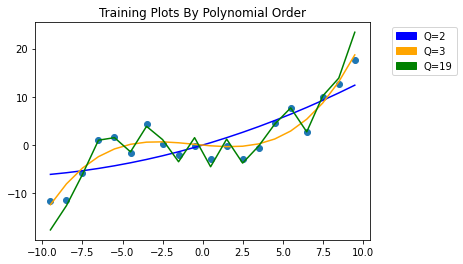

In [11]:
fig, ax = plt.subplots()
ax.set_title("Training Plots By Polynomial Order")
ax.scatter(x_train, y_train)
ax.plot(x_train, np.matmul(np.transpose(w_linreg[0]), np.transpose(z_train[0])), c="blue")
ax.plot(x_train, np.matmul(np.transpose(w_linreg[1]), np.transpose(z_train[1])), c="orange")
ax.plot(x_train, np.matmul(np.transpose(w_linreg[2]), np.transpose(z_train[2])), c="green")
q_2 = mpatches.Patch(color='blue', label='Q=2')
q_3 = mpatches.Patch(color='orange', label='Q=3')
q_19 = mpatches.Patch(color='green', label='Q=19')
plt.legend(bbox_to_anchor=(1.05, 1.0), handles = [q_2, q_3, q_19]) #For ease of reading.
plt.show()

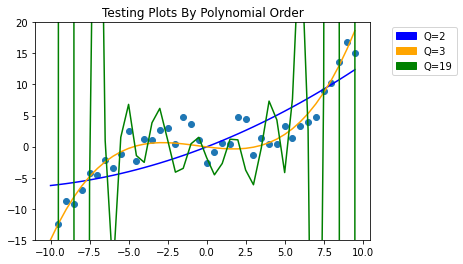

In [12]:
fig, ax = plt.subplots()
ax.set_title("Testing Plots By Polynomial Order")
ax.scatter(x_test, y_test)
ax.set_ylim(-15, 20)
ax.plot(x_test, np.matmul(np.transpose(w_linreg[0]), np.transpose(z_test[0])), c="blue")
ax.plot(x_test, np.matmul(np.transpose(w_linreg[1]), np.transpose(z_test[1])), c="orange")
ax.plot(x_test, np.matmul(np.transpose(w_linreg[2]), np.transpose(z_test[2])), c="green")
q_2 = mpatches.Patch(color='blue', label='Q=2')
q_3 = mpatches.Patch(color='orange', label='Q=3')
q_19 = mpatches.Patch(color='green', label='Q=19')
plt.legend(bbox_to_anchor=(1.05, 1.0), handles = [q_2, q_3, q_19]) #For ease of reading.
plt.show()

In [13]:
#Part 2: Regularization
def getWRegularization(z, y, lamb):
    temp = np.linalg.inv(np.matmul(np.transpose(z), z) + lamb * np.identity(z.shape[1])) #(Z^TZ + lambI)^-1
    temp = np.matmul(z, temp) #(Z^TZ + lambI)^-1Z^T
    w_reg = np.matmul(y, temp) #w = (Z^TZ + lambI)^-1Z^TY
    return w_reg

In [14]:
#w_reg
z_train = getZ(x_train, 6)
w_reg = [getWRegularization(z_train, y_train, 0.1), getWRegularization(z_train, y_train, 100)]
w_reg

[array([-2.16670589e+00, -5.14454505e-01,  3.88349077e-01,  3.10885233e-02,
        -9.04029975e-03, -8.66746571e-05,  5.92808161e-05]),
 array([-7.23251407e-02, -1.28031510e-01,  1.63237028e-01,  1.67666976e-02,
        -3.61243801e-03,  2.86932721e-05,  2.34899106e-05])]

In [15]:
#Training Error
training_error = [error(w_reg[0], z_train, y_train), error(w_reg[1], z_train, y_train)]
training_error

[74.73519896431615, 99.01336690628877]

In [16]:
#Testing Error
z_test = getZ(x_test, 6)
testing_error = [error(w_reg[0], z_test, y_test), error(w_reg[1], z_test, y_test)]
testing_error

[302.2700545849242, 174.6519662352376]

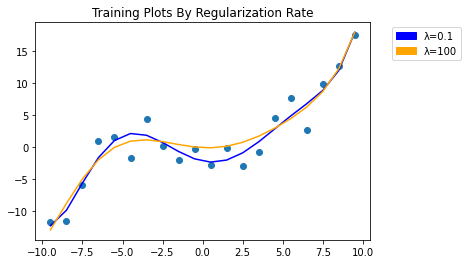

In [17]:
#Train Plot
fig, ax = plt.subplots()
ax.set_title("Training Plots By Regularization Rate")
ax.scatter(x_train, y_train)
ax.plot(x_train, np.matmul(np.transpose(w_reg[0]), np.transpose(z_train)), c="blue")
ax.plot(x_train, np.matmul(np.transpose(w_reg[1]), np.transpose(z_train)), c="orange")
lambda_1 = mpatches.Patch(color='blue', label='λ=0.1')
lambda_2 = mpatches.Patch(color='orange', label='λ=100')
plt.legend(bbox_to_anchor=(1.05, 1.0), handles = [lambda_1, lambda_2]) #For ease of reading.
plt.show()

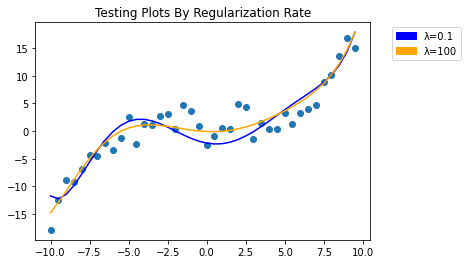

In [18]:
#Test Plot
fig, ax = plt.subplots()
ax.set_title("Testing Plots By Regularization Rate")
ax.scatter(x_test, y_test)
ax.plot(x_test, np.matmul(np.transpose(w_reg[0]), np.transpose(z_test)), c="blue")
ax.plot(x_test, np.matmul(np.transpose(w_reg[1]), np.transpose(z_test)), c="orange")
lambda_1 = mpatches.Patch(color='blue', label='λ=0.1')
lambda_2 = mpatches.Patch(color='orange', label='λ=100')
plt.legend(bbox_to_anchor=(1.05, 1.0), handles = [lambda_1, lambda_2]) #For ease of reading.
plt.show()

In [19]:
#Part 3: Cross-Validation
def leaveOneOut(x, y, lamb):
    w = []
    err = []
    for i in range(0, len(x)):
        x_valid = getZ(x[i:i+1], 6)
        y_valid = y[i:i+1]
        x_train_split = getZ(np.delete(x, i), 6)
        y_train_split = np.delete(y, i)
        w.append(getWRegularization(x_train_split, y_train_split, lamb))
        err.append(error(w[i], x_valid, y_valid))
    return w, err

In [20]:
lambda_val = [0.01, 0.1, 1, 10, 100, 1000, 1000000]
for i in lambda_val:
    w, err = leaveOneOut(x_train, y_train, i)
    index = err.index(min(err)) #Smallest error. 
    print("λ= " + str(i) + " Error: " +  str(error(w[index], getZ(x_test, 6), y_test)))

λ= 0.01 Error: 302.12862243895097
λ= 0.1 Error: 298.50688300308957
λ= 1 Error: 270.79964082439153
λ= 10 Error: 206.38397541813066
λ= 100 Error: 174.589846811803
λ= 1000 Error: 160.7916569485896
λ= 1000000 Error: 183.10807895729934


In [21]:
def kFold(x, y, lamb, k):
    w = []
    err = []
    limit = len(x)/k #Size of each fold.
    for i in range(0, int(k)): #Number of folds. 
        j = limit * i
        array_range = np.arange(int(j), int(j+limit))
        x_valid = getZ(x[array_range], 6)
        y_valid = y[array_range]
        x_train_split = getZ(np.delete(x, array_range), 6)
        y_train_split = np.delete(y, array_range)
        w.append(getWRegularization(x_train_split, y_train_split, lamb))
        err.append(error(w[i], x_valid, y_valid))
    return w, err

In [22]:
lambda_val = [0.01, 0.1, 1, 10, 100, 1000, 1000000]
for i in lambda_val:
    w, err = kFold(x_train, y_train, i, 5)
    index = err.index(min(err)) #Smallest error. 
    print("λ= " + str(i) + " Error: " +  str(error(w[index], getZ(x_test, 6), y_test)))

λ= 0.01 Error: 462.3974719758674
λ= 0.1 Error: 425.9057331715244
λ= 1 Error: 285.8320453534039
λ= 10 Error: 198.74532898098755
λ= 100 Error: 175.90997234902528
λ= 1000 Error: 160.9398199365383
λ= 1000000 Error: 183.18363213955288
